# Exploratory Data Analysis (EDA) learning resources

**Sources of questions that EDA can answer:**

https://www.linkedin.com/pulse/15-questions-ask-during-exploratory-data-analysis-vikash-singh

https://medium.com/@gauravtopre9/questions-to-ask-while-eda-1a19f82fbc5d

https://www.quanthub.com/how-do-i-use-questions-to-guide-exploratory-data-analysis/

https://shopify.engineering/conducting-exploratory-data-analysis#

**Sources of code for EDA:**

https://www.kaggle.com/code/ekami66/detailed-exploratory-data-analysis-with-python#Exploratory-data-analysis-(EDA)

https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/#h-step-13-eda-multivariate-analysis

# Data source

https://www.kaggle.com/datasets/hopesb/hr-analytics-dataset?select=Cleaned_HR_Data_Analysis.csv

>The uploaded dataset contains detailed information about employees, training programs, and other HR-related metrics"

See the link for more information about the data set.

There is a column called "EmployeeStatus" that tells us if an employee is still employed or whether their contract has been terminated.

We can use the data to understand what features may influence whether employment is terminated or still active. i.e. Why might people leave this company?

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly
import scipy
import seaborn as sns

In [3]:
data = pd.read_csv('Cleaned_HR_Data_Analysis.csv')

In [4]:
data.head()

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
0,3427,20-Sep-19,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,...,1,2,3,15-Jul-23,Leadership Development,Internal,Failed,2,606.11,50
1,3428,11-Feb-23,Production Technician I,EW,Active,Contract,Zone A,Part-Time,Production,Aerial,...,2,1,5,12-Sep-22,Customer Service,External,Incomplete,4,673.02,58
2,3429,10-Dec-18,Area Sales Manager,PL,Active,Full-Time,Zone B,Part-Time,Sales,General - Sga,...,1,2,1,13-Aug-22,Leadership Development,External,Failed,2,413.28,27
3,3430,21-Jun-21,Area Sales Manager,CCDR,Active,Contract,Zone A,Full-Time,Sales,Finance & Accounting,...,5,5,4,15-Dec-22,Project Management,External,Completed,3,663.78,23
4,3431,29-Jun-19,Area Sales Manager,TNS,Active,Contract,Zone A,Temporary,Sales,General - Con,...,2,5,3,13-Jul-23,Technical Skills,External,Failed,5,399.03,50


# Contents

This notebook has intentionally not been commented on so that you can include your own notes and information. 

There are two sections to this notebook:

a) Data structure, distributions, null values, duplicates and outliers

b) Correlations and relationships

We will cover feature engineering in another session.

Each section analyses the data to understand more about it. At the start of each section there are example questions that have been answered below it using Python code.

# a) Data structure, distributions, nulls, duplicates and outliers

Example questions:

**Data structure and distribution**

1. How many features do you have?
2. How many observations do you have?
3. What is the data type of each feature?
4. From what you know about the features of your dataset, do the data types make sense? Do you need to change any?
5. Do you have null values?
6. How much memory does this dataset use? Could this pose a problem for you later on?
7. What is the distribution of each variable?
8. Do there appear to be outliers?
9. Think about what the variables mean and what the histograms say about their values and their spread — are there any surprises?
10. Are the max/min values reasonable for the variables? Do you see any values that look like errors?
11. What is the mean for each variable? What do the means tell you about your dataset as a whole?


**Null Values & Duplicates**

1. Check the duplicated sum.
2. Is the null value a result of the way data was recorded? (Was it kept Null Intentionally — we can decide this by carefully understanding the data)
3. Can you drop the rows with null values without it significantly affecting your analysis?
4. Looking at the distributions of the variables, can you justify filling in the missing values with the mean or median for that variable? (We use mean for Numerical Data with no Outliers, Median for Numerical Data with Outliers and we use Mode for Categorical data)
5. If your data is time-series data, can you fill the missing values with interpolation?
6. Are there so many missing values for a variable that you should drop that variable from your dataset?


**Outliers**

1. Do you have outliers in your variables?
2. Why do you think you have outliers?
3. Do the outliers represent real observations (i.e. not errors)?
4. Should you exclude these observations?

## Counts, nulls and data types

In [5]:
# Check the number of columns (features) and their names
# This answers how many features are in the dataset and what they are called, which is important for understanding the structure of the data and planning the analysis.
print(f"""{len(data.columns)}
{data.columns}
""")

28
Index(['Employee ID', 'StartDate', 'Title', 'BusinessUnit', 'EmployeeStatus',
       'EmployeeType', 'PayZone', 'EmployeeClassificationType',
       'DepartmentType', 'Division', 'DOB', 'State', 'GenderCode', 'RaceDesc',
       'MaritalDesc', 'Performance Score', 'Current Employee Rating',
       'Survey Date', 'Engagement Score', 'Satisfaction Score',
       'Work-Life Balance Score', 'Training Date', 'Training Program Name',
       'Training Type', 'Training Outcome', 'Training Duration(Days)',
       'Training Cost', 'Age'],
      dtype='str')



In [6]:
# Check the data types of each column and look for any missing values
# This answers how many observations are in the dataset, what types of data are in each column, and whether there are any missing values, which is important for data cleaning and preprocessing.
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2845 entries, 0 to 2844
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee ID                 2845 non-null   int64  
 1   StartDate                   2845 non-null   str    
 2   Title                       2845 non-null   str    
 3   BusinessUnit                2845 non-null   str    
 4   EmployeeStatus              2845 non-null   str    
 5   EmployeeType                2845 non-null   str    
 6   PayZone                     2845 non-null   str    
 7   EmployeeClassificationType  2845 non-null   str    
 8   DepartmentType              2845 non-null   str    
 9   Division                    2845 non-null   str    
 10  DOB                         2845 non-null   str    
 11  State                       2845 non-null   str    
 12  GenderCode                  2845 non-null   str    
 13  RaceDesc                    2845 non-null   

- The output shows there are 2845 observations.

In [7]:
# Check for missing values in each column
# This answers how many missing values are in each column, which is important for deciding how to handle them in the analysis.
data.isnull().sum()

Employee ID                   0
StartDate                     0
Title                         0
BusinessUnit                  0
EmployeeStatus                0
EmployeeType                  0
PayZone                       0
EmployeeClassificationType    0
DepartmentType                0
Division                      0
DOB                           0
State                         0
GenderCode                    0
RaceDesc                      0
MaritalDesc                   0
Performance Score             0
Current Employee Rating       0
Survey Date                   0
Engagement Score              0
Satisfaction Score            0
Work-Life Balance Score       0
Training Date                 0
Training Program Name         0
Training Type                 0
Training Outcome              0
Training Duration(Days)       0
Training Cost                 0
Age                           0
dtype: int64

In [8]:
# Convert the data types of the columns to more appropriate types
# This answers whether the data types of the columns are appropriate for the analysis and whether they need to be converted, which is important for ensuring that the analysis is accurate and efficient.
data_dtypes_converted = data.convert_dtypes()

# Check the data types of each column after conversion
data_dtypes_converted.dtypes

Employee ID                     Int64
StartDate                      string
Title                          string
BusinessUnit                   string
EmployeeStatus                 string
EmployeeType                   string
PayZone                        string
EmployeeClassificationType     string
DepartmentType                 string
Division                       string
DOB                            string
State                          string
GenderCode                     string
RaceDesc                       string
MaritalDesc                    string
Performance Score              string
Current Employee Rating         Int64
Survey Date                    string
Engagement Score                Int64
Satisfaction Score              Int64
Work-Life Balance Score         Int64
Training Date                  string
Training Program Name          string
Training Type                  string
Training Outcome               string
Training Duration(Days)         Int64
Training Cos

In [9]:
# Check the number of unique values in each column  
# This answers how many unique values are in each column, which is important for understanding the variability of the data and identifying potential categorical variables.
data.nunique()

Employee ID                   2845
StartDate                     1472
Title                           32
BusinessUnit                    10
EmployeeStatus                   2
EmployeeType                     3
PayZone                          3
EmployeeClassificationType       3
DepartmentType                   6
Division                        25
DOB                           2664
State                           28
GenderCode                       2
RaceDesc                         5
MaritalDesc                      4
Performance Score                4
Current Employee Rating          5
Survey Date                    366
Engagement Score                 5
Satisfaction Score               5
Work-Life Balance Score          5
Training Date                  366
Training Program Name            5
Training Type                    2
Training Outcome                 4
Training Duration(Days)          5
Training Cost                 2813
Age                             66
dtype: int64

In [10]:
# Define the column types based on the data dictionary and the unique values in each column
# This answers how to categorize the columns into different types (unique identifier, date, numerical, ordinal, nominal), which is important for choosing appropriate analysis techniques and visualizations for each type of data.
unique_id_col = ['Employee ID']
date_cols = ['StartDate', 'DOB', 'Survey Date', 'Training Date']
numerical_cols = ['Training Cost', 'Training Duration(Days)', 'Age']
ordinal_cols = ['PayZone', 'Performance Score', 'Current Employee Rating', 'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score']

# Define the nominal columns by dropping the other column types from the original columns
# This answers which columns are nominal by excluding the unique identifier, date, numerical, and ordinal columns, which is important for identifying categorical variables that do not have a natural order.
nominal_cols = data.columns.drop(unique_id_col).drop(date_cols).drop(numerical_cols).drop(ordinal_cols)

## Duplicates

In [11]:
# Check the number of unique values in the unique identifier column
# This is important for understanding the uniqueness of each record and identifying potential duplicates.
print(data[unique_id_col].nunique())

# Check the number of unique values in the unique identifier column after dropping duplicates
# This is important for confirming that there are no duplicate records in the dataset, which could affect the analysis and results.
print(data[unique_id_col].drop_duplicates().nunique())


Employee ID    2845
dtype: int64
Employee ID    2845
dtype: int64


In [12]:
# Check for duplicate values in the unique identifier column
# This is important for identifying any duplicate records in the dataset, which could affect the analysis and results.
data[unique_id_col].duplicated(keep=False).sum()

np.int64(0)

## Distribution and outliers

### Nominal variables structure and distributions

In [13]:
# Display the first few rows of the nominal columns
# This is important for understanding the categorical variables in the dataset and their potential values, which can inform the choice of analysis techniques and visualizations.
data[nominal_cols].head()

,Title,BusinessUnit,EmployeeStatus,EmployeeType,EmployeeClassificationType,DepartmentType,Division,State,GenderCode,RaceDesc,MaritalDesc,Training Program Name,Training Type,Training Outcome
0,Production Technician I,CCDR,Active,Contract,Temporary,Production,Finance & Accounting,MA,Female,White,Widowed,Leadership Development,Internal,Failed
1,Production Technician I,EW,Active,Contract,Part-Time,Production,Aerial,MA,Male,Hispanic,Widowed,Customer Service,External,Incomplete
2,Area Sales Manager,PL,Active,Full-Time,Part-Time,Sales,General - Sga,MA,Male,Hispanic,Widowed,Leadership Development,External,Failed
3,Area Sales Manager,CCDR,Active,Contract,Full-Time,Sales,Finance & Accounting,ND,Male,Other,Single,Project Management,External,Completed
4,Area Sales Manager,TNS,Active,Contract,Temporary,Sales,General - Con,FL,Female,Other,Married,Technical Skills,External,Failed



Title
Enterprise Architect               2
Sr. DBA                            4
Data Architect                     5
Principal Data Architect           6
Software Engineering Manager       7
Data Analyst                       8
Sr. Accountant                    10
CIO                               11
Director of Sales                 11
IT Director                       11
President & CEO                   11
BI Director                       11
Director of Operations            11
IT Manager - Infra                11
IT Manager - Support              11
Shared Services Manager           20
IT Manager - DB                   22
Database Administrator            25
Senior BI Developer               30
Sales Manager                     30
Administrative Assistant          33
Accountant I                      33
Sr. Network Engineer              41
BI Developer                      44
Data Analyst                      47
Network Engineer                  55
IT Support                     

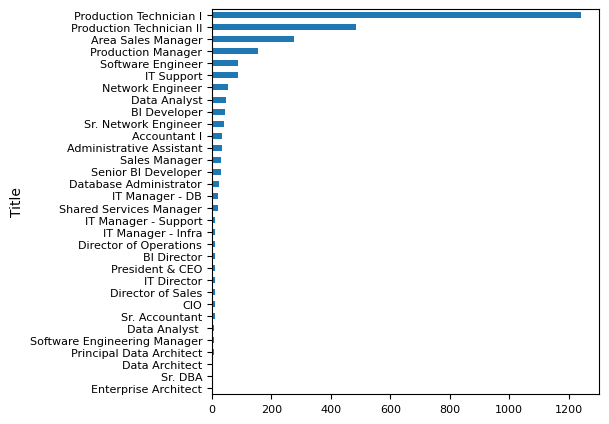


BusinessUnit
SVG     281
EW      282
MSC     282
PL      283
TNS     283
CCDR    284
PYZ     285
WBL     286
BPC     288
NEL     291
Name: BusinessUnit, dtype: int64
          


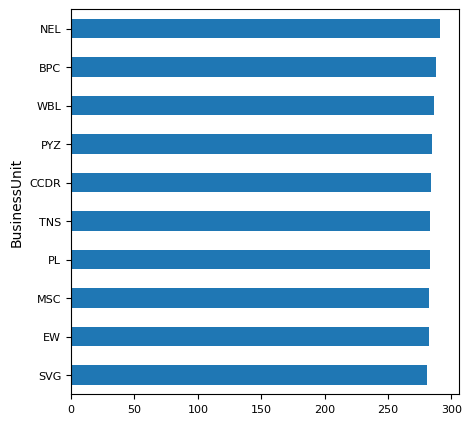


EmployeeStatus
Terminated     387
Active        2458
Name: EmployeeStatus, dtype: int64
          


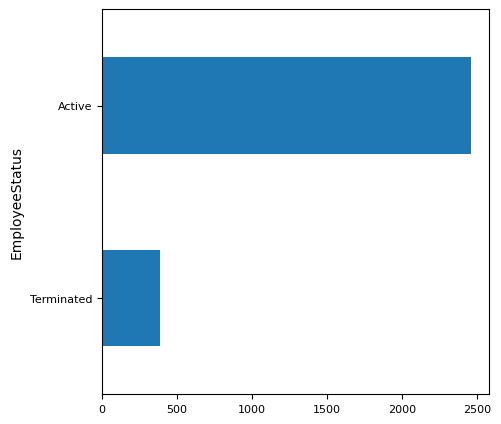


EmployeeType
Part-Time    897
Contract     951
Full-Time    997
Name: EmployeeType, dtype: int64
          


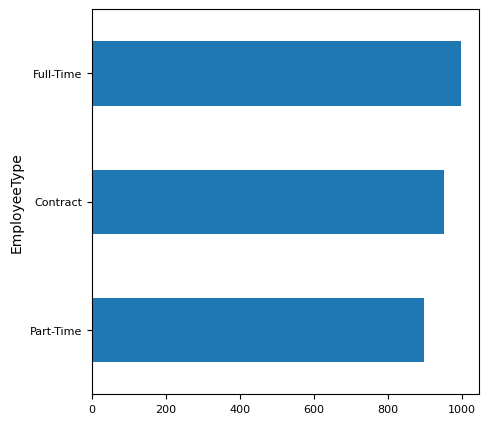


EmployeeClassificationType
Part-Time    899
Full-Time    966
Temporary    980
Name: EmployeeClassificationType, dtype: int64
          


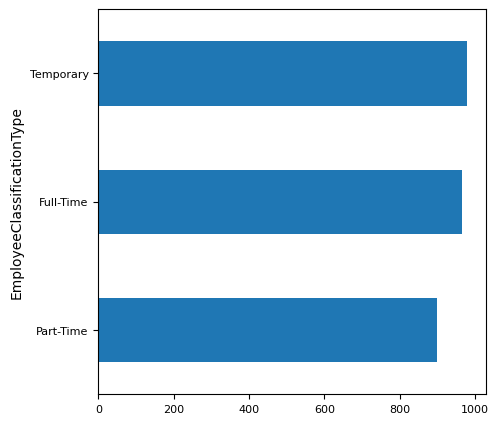


DepartmentType
Executive Office          24
Admin Offices             79
Software Engineering     112
Sales                    311
IT/IS                    409
Production              1910
Name: DepartmentType, dtype: int64
          


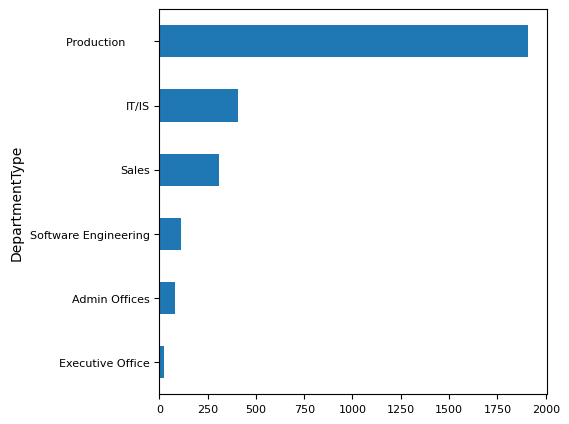


Division
Corp Operations               2
Sales & Marketing             8
Safety                        8
Isp                          14
Project Management - Eng     15
Technology / It              21
Billable Consultants         23
People Services              24
Underground                  31
Wireless                     32
Executive                    41
Shop (Fleet)                 53
Catv                         54
Yard (Material Handling)     55
Finance & Accounting         69
Fielders                     80
General - Eng                85
Splicing                    108
General - Sga               112
Project Management - Con    172
Wireline Construction       175
Aerial                      181
Engineers                   261
General - Con               474
Field Operations            747
Name: Division, dtype: int64
          


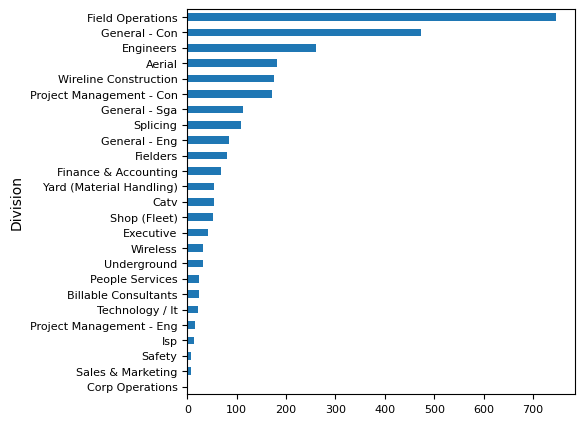


State
FL       1
NV       1
MT       1
OH       1
VA       2
UT       2
NH       2
ME       2
GA       3
ND       4
VT       4
RI       4
NC       5
OR       9
CA      10
AL      11
NY      11
PA      13
IN      14
WA      20
CO      21
TN      24
KY      27
ID      31
AZ      31
CT      33
TX      35
MA    2523
Name: State, dtype: int64
          


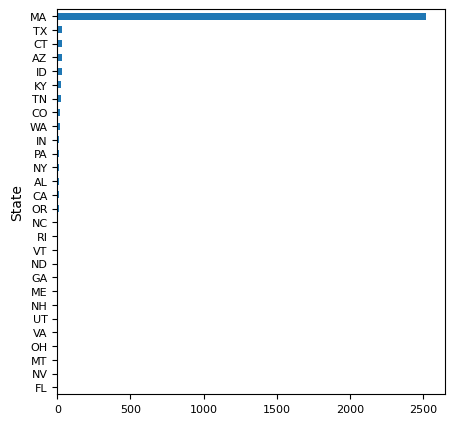


GenderCode
Male      1257
Female    1588
Name: GenderCode, dtype: int64
          


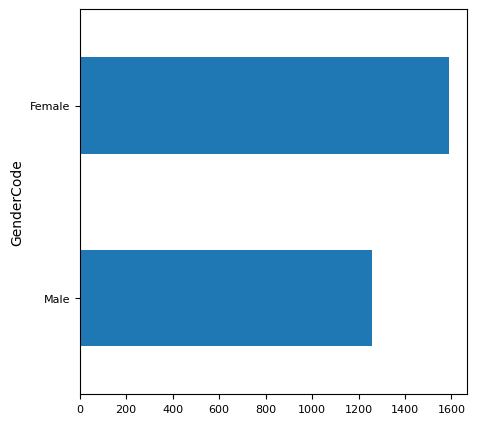


RaceDesc
Hispanic    540
Other       556
White       572
Black       579
Asian       598
Name: RaceDesc, dtype: int64
          


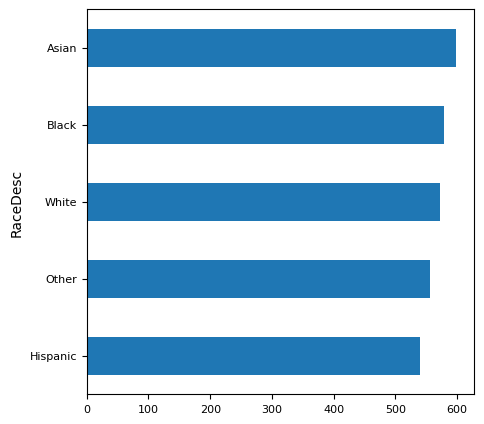


MaritalDesc
Widowed     684
Divorced    700
Married     730
Single      731
Name: MaritalDesc, dtype: int64
          


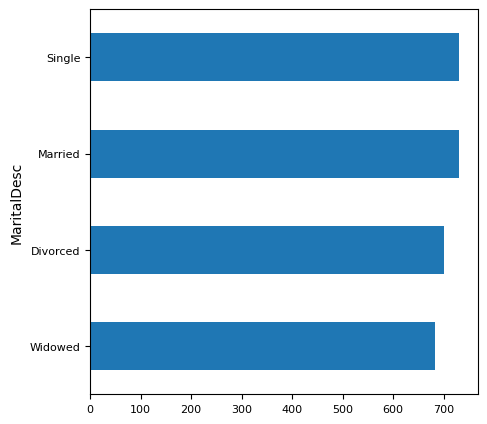


Training Program Name
Customer Service          540
Technical Skills          543
Leadership Development    544
Project Management        585
Communication Skills      633
Name: Training Program Name, dtype: int64
          


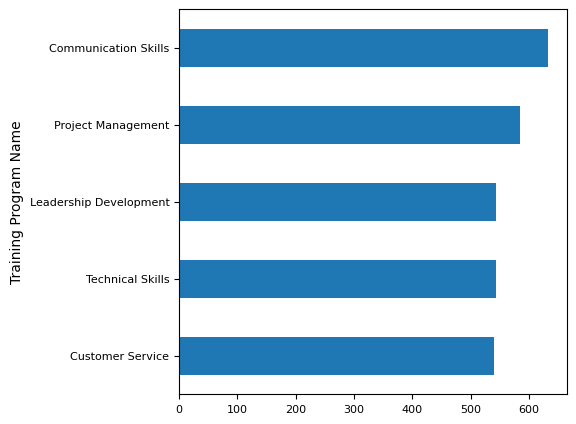


Training Type
Internal    1421
External    1424
Name: Training Type, dtype: int64
          


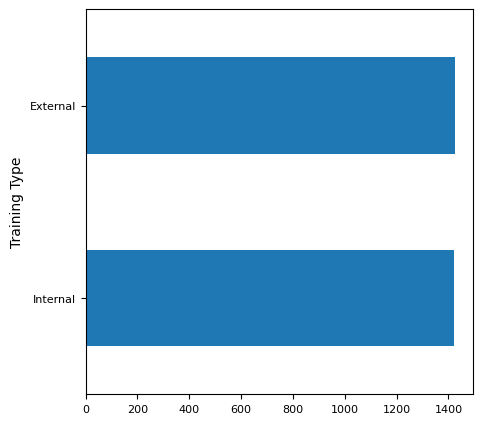


Training Outcome
Failed        668
Passed        709
Incomplete    731
Completed     737
Name: Training Outcome, dtype: int64
          


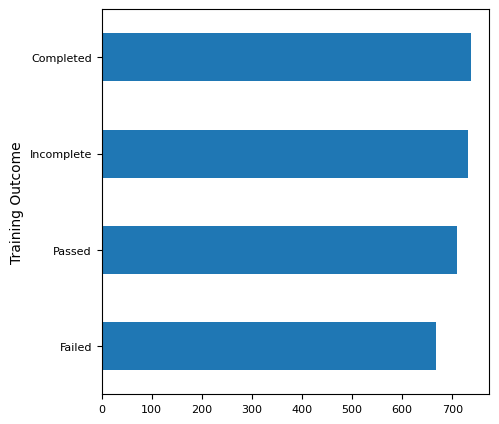

In [14]:
# Display the value counts for each nominal column
# This answers the distribution of values in each nominal column, which is important for understanding the categorical variables and identifying any imbalances or patterns in the data.

for i in range(len(nominal_cols)):
    col_name = nominal_cols[i]
    counts = pd.Series(data[col_name].value_counts(), name=col_name).sort_values(ascending=True)


    print(f"""
{counts}
          """)
    counts.plot(kind='barh', fontsize=8, figsize=(5, 5))
    plt.show()

### Date variables structure and distributions

In [15]:
# Display the first few rows of the date columns
data[date_cols].head()

,StartDate,DOB,Survey Date,Training Date
0,20-Sep-19,07-10-1969,14-01-2023,15-Jul-23
1,11-Feb-23,30-08-1965,09-09-2022,12-Sep-22
2,10-Dec-18,06-10-1991,27-05-2023,13-Aug-22
3,21-Jun-21,04-04-1998,16-06-2023,15-Dec-22
4,29-Jun-19,29-08-1969,25-11-2022,13-Jul-23


In [16]:
# Check the data types of the date columns
# This is important for confirming that the date columns are in the correct format for analysis and visualization, which can affect the accuracy and efficiency of the analysis.
data[date_cols].dtypes

StartDate        str
DOB              str
Survey Date      str
Training Date    str
dtype: object

In [17]:
# 
data[date_cols].convert_dtypes().dtypes

StartDate        string
DOB              string
Survey Date      string
Training Date    string
dtype: object

https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior
https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html

In [18]:
# Convert the date columns to datetime format and create new columns for the transformed dates
# This answers whether the date columns can be successfully converted to datetime format, which is important for enabling date-based analysis and visualizations, such as time series analysis or calculating durations between dates.
date_transformed_cols = []

for i in range(len(date_cols)):
    col = date_cols[i]
    new_col_name = col+'_transformed'
    data = pd.concat([data, pd.to_datetime(data.loc[:,col], format='mixed').rename(new_col_name)], axis='columns')
    date_transformed_cols += [new_col_name]


print(f"""{data[date_transformed_cols].head()}

{data[date_transformed_cols].dtypes}
""")

  StartDate_transformed DOB_transformed Survey Date_transformed  \
0            2019-09-20      1969-07-10              2023-01-14   
1            2023-02-11      1965-08-30              2022-09-09   
2            2018-12-10      1991-06-10              2023-05-27   
3            2021-06-21      1998-04-04              2023-06-16   
4            2019-06-29      1969-08-29              2022-11-25   

  Training Date_transformed  
0                2023-07-15  
1                2022-09-12  
2                2022-08-13  
3                2022-12-15  
4                2023-07-13  

StartDate_transformed        datetime64[us]
DOB_transformed              datetime64[us]
Survey Date_transformed      datetime64[us]
Training Date_transformed    datetime64[us]
dtype: object



In [19]:
# Display the summary statistics for the transformed date columns
# This is important for understanding the range and distribution of the date values, which can inform the choice of analysis techniques and visualizations for date-based data.
data[date_transformed_cols].describe().T

,count,mean,min,25%,50%,75%,max
StartDate_transformed,2845,2021-02-01 14:08:48.927943,2018-08-07 00:00:00,2019-11-05 00:00:00,2021-02-08 00:00:00,2022-05-02 00:00:00,2023-08-06 00:00:00
DOB_transformed,2845,1971-08-21 07:30:58.840070,1941-02-10 00:00:00,1956-08-07 00:00:00,1972-01-08 00:00:00,1987-04-27 00:00:00,2001-11-04 00:00:00
Survey Date_transformed,2845,2023-02-06 01:46:17.504393,2022-01-09 00:00:00,2022-10-23 00:00:00,2023-02-15 00:00:00,2023-05-28 00:00:00,2023-12-07 00:00:00
Training Date_transformed,2845,2023-02-02 22:22:18.769771,2022-08-05 00:00:00,2022-11-06 00:00:00,2023-02-03 00:00:00,2023-05-02 00:00:00,2023-08-05 00:00:00


### Numerical variables structure and distributions

In [20]:
# Display the first few rows of the numerical columns
data[numerical_cols].head()

,Training Cost,Training Duration(Days),Age
0,606.11,2,50
1,673.02,4,58
2,413.28,2,27
3,663.78,3,23
4,399.03,5,50


In [21]:
# Display the summary statistics for the numerical columns
data[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Training Cost,2845.0,559.278956,263.333611,100.04,328.06,571.81,788.33,999.97
Training Duration(Days),2845.0,2.973989,1.419682,1.00,2.00,3.00,4.00,5.00
Age,2845.0,49.448506,17.689179,17.00,34.00,49.00,65.00,82.00


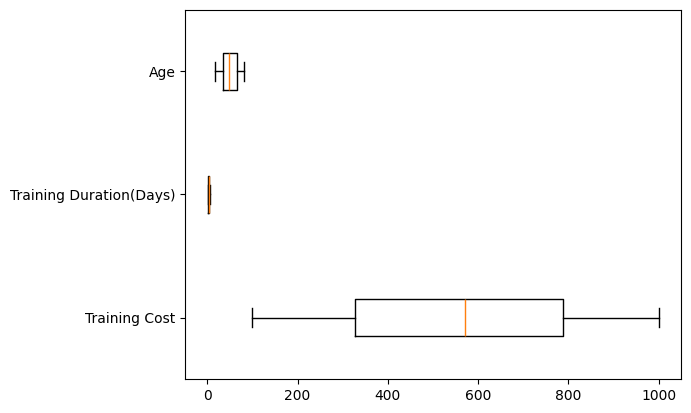

In [22]:
# Create boxplots for the numerical columns
# This answers the distribution and potential outliers in the numerical columns, which is important for understanding the variability of the data and identifying any potential issues that may need to be addressed in the analysis.
plt.boxplot(data[numerical_cols],
            tick_labels=numerical_cols,
            vert=False
            );

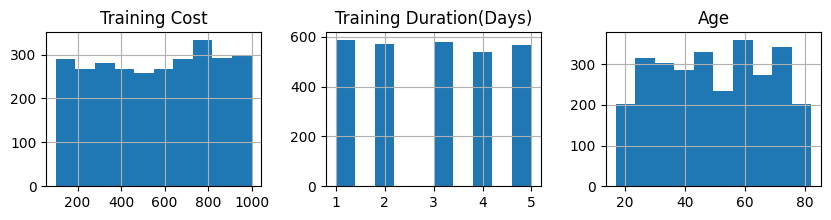

In [23]:

# Create histograms for the numerical columns
# This is important for understanding the distribution of the numerical values, which can inform the choice of analysis techniques and visualizations for numerical data.

data.hist(numerical_cols, figsize=(10, 2), layout=(1,3));

https://docs.scipy.org/doc/scipy/reference/stats.html

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html

In [24]:
scipy.stats.fit(dist=scipy.stats.uniform, data=data['Training Cost'].values.T, bounds=((0, 10000), (0, 10000)))

  params: FitParams(loc=np.float64(98.96390981697732), scale=np.float64(904.2642703745387))
 success: True
 message: 'Optimization terminated successfully.'

### Ordinal variables structure and distributions

In [25]:
data[ordinal_cols].head()

,PayZone,Performance Score,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score
0,Zone C,Fully Meets,4,1,2,3
1,Zone A,Fully Meets,3,2,1,5
2,Zone B,Fully Meets,4,1,2,1
3,Zone A,Fully Meets,2,5,5,4
4,Zone A,Fully Meets,3,2,5,3


In [26]:
data['Performance Score'].value_counts().sort_index()

Performance Score
Exceeds               346
Fully Meets          2251
Needs Improvement     162
PIP                    86
Name: count, dtype: int64

In [27]:
data['PayZone'].value_counts().sort_index()

PayZone
Zone A    1013
Zone B     934
Zone C     898
Name: count, dtype: int64

In [28]:
performance_score_dict = {'PIP': 1,
                          'Needs Improvement': 2,
                          'Fully Meets': 3,
                          'Exceeds': 4}

payzone_dict = {'Zone A': 1,
                'Zone B': 2,
                'Zone C': 3}

In [29]:
data['Performance Score_transformed'] = data['Performance Score'].map(performance_score_dict)

data['PayZone_transformed'] = data['PayZone'].map(payzone_dict)

ordinal_cols_transformed = ordinal_cols
ordinal_cols_transformed.remove('Performance Score')
ordinal_cols_transformed.remove('PayZone')
ordinal_cols_transformed += ['Performance Score_transformed']
ordinal_cols_transformed += ['PayZone_transformed']

In [30]:
data[ordinal_cols_transformed].describe().T

,count,mean,std,min,25%,50%,75%,max
Current Employee Rating,2845.0,2.974692,1.012610,1.0,2.0,3.0,3.0,5.0
Engagement Score,2845.0,2.941652,1.435230,1.0,2.0,3.0,4.0,5.0
Satisfaction Score,2845.0,3.028471,1.410067,1.0,2.0,3.0,4.0,5.0
Work-Life Balance Score,2845.0,2.989104,1.408816,1.0,2.0,3.0,4.0,5.0
Performance Score_transformed,2845.0,3.004218,0.547321,1.0,3.0,3.0,3.0,4.0
PayZone_transformed,2845.0,1.959578,0.818722,1.0,1.0,2.0,3.0,3.0


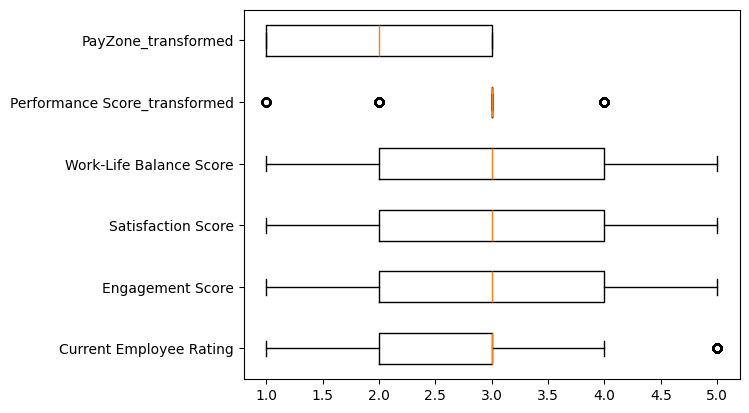

In [31]:
plt.boxplot(data[ordinal_cols_transformed],
            tick_labels=ordinal_cols_transformed,
            vert=False
            );

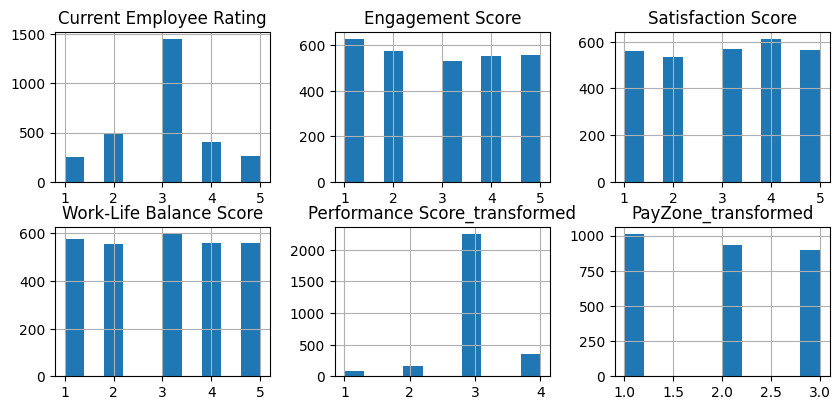

In [32]:
data.hist(ordinal_cols_transformed, figsize=(10, 7), layout=(3,3));


Current Employee Rating
1     252
2     483
3    1451
4     403
5     256
Name: Current Employee Rating, dtype: int64
          


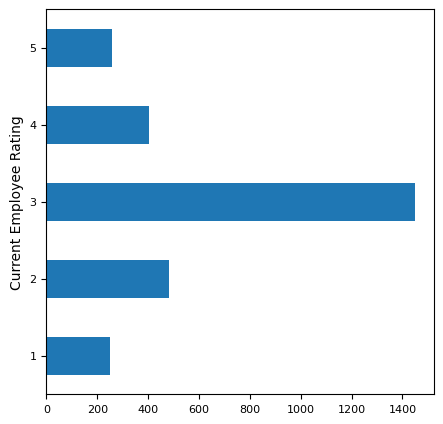


Engagement Score
1    628
2    576
3    532
4    552
5    557
Name: Engagement Score, dtype: int64
          


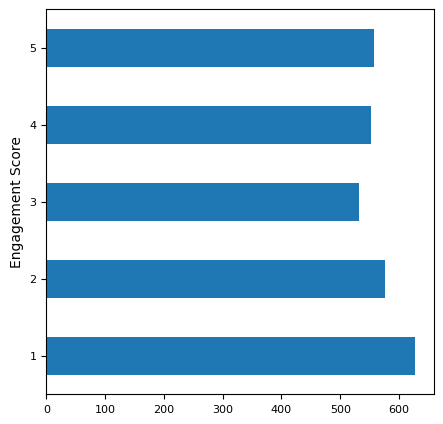


Satisfaction Score
1    562
2    537
3    569
4    612
5    565
Name: Satisfaction Score, dtype: int64
          


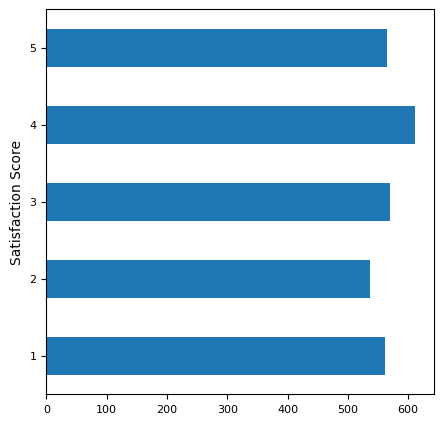


Work-Life Balance Score
1    575
2    555
3    599
4    558
5    558
Name: Work-Life Balance Score, dtype: int64
          


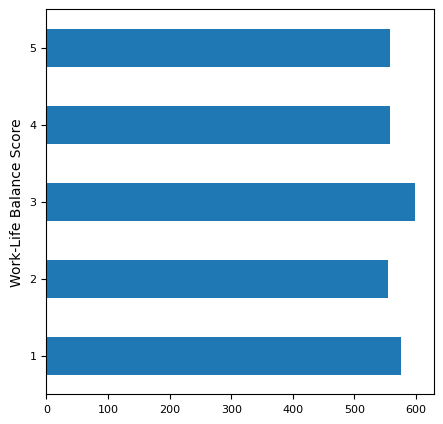


Performance Score_transformed
1      86
2     162
3    2251
4     346
Name: Performance Score_transformed, dtype: int64
          


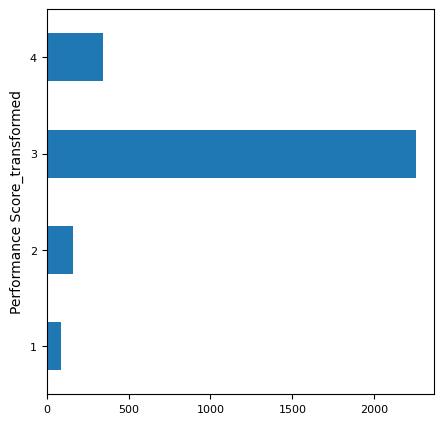


PayZone_transformed
1    1013
2     934
3     898
Name: PayZone_transformed, dtype: int64
          


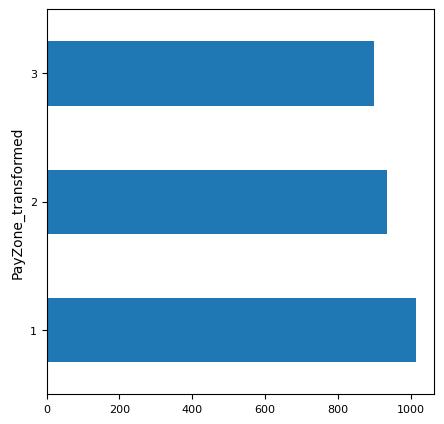

In [33]:
for i in range(len(ordinal_cols)):
    col_name = ordinal_cols[i]
    counts = pd.Series(data[col_name].value_counts(), name=col_name).sort_index(ascending=True)


    print(f"""
{counts}
          """)
    counts.plot(kind='barh', fontsize=8, figsize=(5, 5))
    plt.show()

# b) Correlations and relationships

Examples of questions:

1. Which variables are most correlated with your target variable? (If applicable)
2. Is there multicollinearity? (Two or more features that have a strong correlation) How will this affect your model?
3. Do you have variables that represent the same information? Can one be dropped?

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

<Axes: >

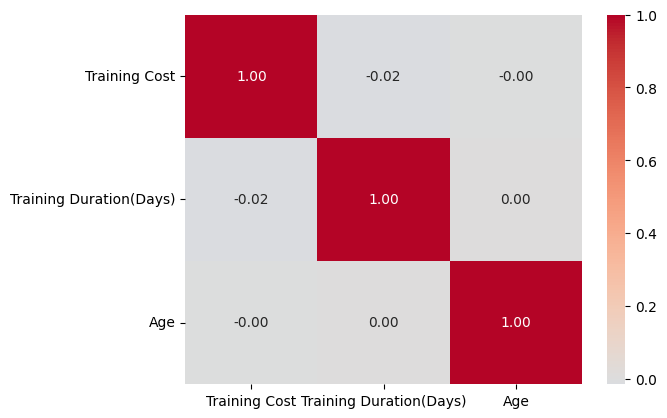

In [34]:
sns.heatmap(data[numerical_cols].corr(method="pearson"), annot=True, fmt=".2f", cmap='coolwarm', center=0)

<Axes: >

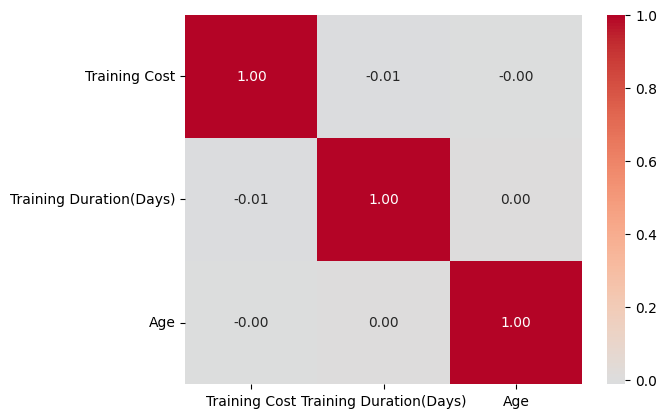

In [35]:
sns.heatmap(data[numerical_cols].corr(method="kendall"), annot=True, fmt=".2f", cmap='coolwarm', center=0)

<Axes: >

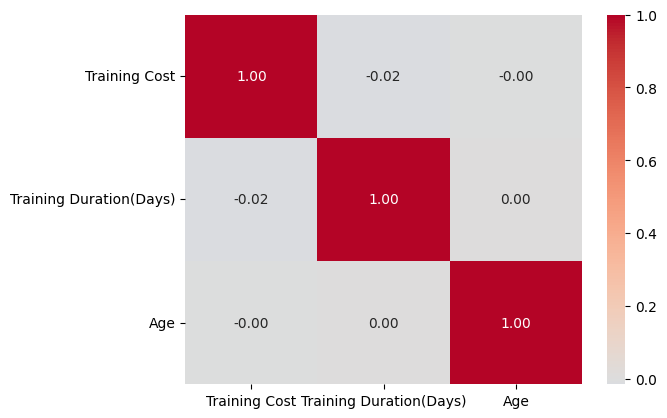

In [36]:
sns.heatmap(data[numerical_cols].corr(method="spearman"), annot=True, fmt=".2f", cmap='coolwarm', center=0)

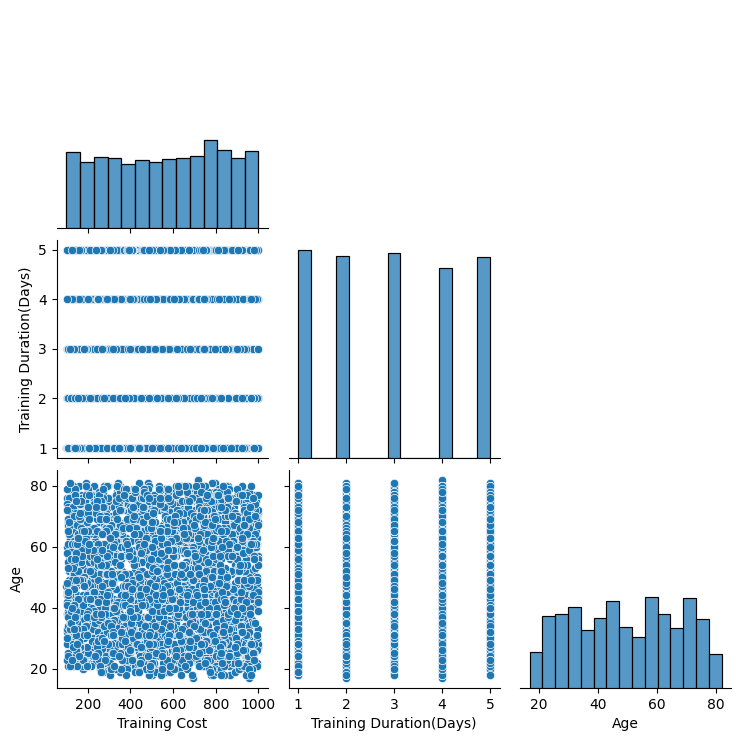

In [37]:
sns.pairplot(data[numerical_cols], corner=True);